<a href="https://colab.research.google.com/github/Pumlisa97/mit805-airline-delays-pyspark/blob/main/notebooks/03_part2_mapreduce_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIT 805: Large Scale Data Analytics
## Part 2 – Distributed Data Processing with PySpark MapReduce

### Topic
Analysis of US Airline Delay Patterns and Root Causes (2020–2024)

### Project Objective

This study analyses United States airline flight data between 2020 and 2024 using Apache Spark.

The analysis aims to answer three key questions:

1. Did airline delays increase between 2020 and 2024?
2. Are flights departing later in the day more likely to be delayed?
3. What are the primary causes of airline delays?

To answer these questions, approximately 14.1 GB of airline records were processed using a distributed MapReduce-style framework implemented in Apache Spark.

# Section 1: Dataset Validation and Environment Setup

The analytical environment is connected to Google Drive to provide access to the source data and a persistent location for analytical outputs.

In [ ]:
from google.colab import drive
drive.mount("/content/drive", timeout_ms=300000)

Mounted at /content/drive


In [ ]:
from pathlib import Path

project_root = Path("/content/drive/MyDrive/MIT805_Airline_Delays")
working_dir = project_root / "data" / "working"

print("Drive accessible:", Path("/content/drive/MyDrive").exists())
print("Project folder exists:", project_root.exists())
print("Working folder exists:", working_dir.exists())

Drive accessible: True
Project folder exists: True
Working folder exists: True


### Dataset Coverage Verification

Before processing begins, the airline dataset is validated to ensure complete monthly coverage across the entire study period.

The validation process confirms:

- All expected files are present
- The study period spans 2020–2024
- The input size reflects a genuinely large-scale analytical workload

In [ ]:
from pathlib import Path
import re

PROJECT_ROOT = Path("/content/drive/MyDrive/MIT805_Airline_Delays")
WORKING_DIR = PROJECT_ROOT / "data" / "working"
PART2_OUTPUT = PROJECT_ROOT / "output" / "part2"

def extract_year_month(filename):
    match = re.search(r"_(\d{4})_(\d{1,2})\.csv$", filename)
    return (int(match.group(1)), int(match.group(2))) if match else None

expected_periods = {
    (year, month)
    for year in range(2020, 2025)
    for month in range(1, 13)
}

selected_csvs = sorted(
    path for path in WORKING_DIR.glob("*.csv")
    if extract_year_month(path.name) in expected_periods
)

observed_periods = {
    extract_year_month(path.name)
    for path in selected_csvs
}

input_bytes = sum(path.stat().st_size for path in selected_csvs)

print("Selected CSV files:", len(selected_csvs))
print("Observed year-month periods:", len(observed_periods))
print("Missing periods:", sorted(expected_periods - observed_periods))
print("Input size:", f"{input_bytes / 1_000_000_000:.3f} GB")
print("Input size:", f"{input_bytes / 1024**3:.3f} GiB")

assert len(selected_csvs) == 60, "Expected exactly 60 selected CSV files."
assert observed_periods == expected_periods, "Year-month coverage is incomplete."

evidence_dir = PART2_OUTPUT / "execution_evidence"
evidence_dir.mkdir(parents=True, exist_ok=True)

evidence = (
    f"Selected CSV files: {len(selected_csvs)}\n"
    f"Observed year-month periods: {len(observed_periods)}\n"
    f"Missing periods: {sorted(expected_periods - observed_periods)}\n"
    f"Input size: {input_bytes / 1_000_000_000:.3f} GB\n"
    f"Input size: {input_bytes / 1024**3:.3f} GiB\n"
)
(evidence_dir / "input_size_validation.txt").write_text(evidence)

print("Input validation evidence saved.")

Selected CSV files: 60
Observed year-month periods: 60
Missing periods: []
Input size: 14.130 GB
Input size: 13.159 GiB
Input validation evidence saved.


### Business Relevance

The validation confirms complete temporal coverage across all 60 monthly datasets. This provides confidence that subsequent findings are based on a complete representation of airline operations over the study period.

The dataset size of approximately 14.1 GB also demonstrates the need for distributed processing technologies such as Apache Spark.

# Section 2: Spark Data Preparation

A Spark session is created and the airline datasets are loaded into a distributed processing environment.

To improve performance and reduce memory consumption, only the variables required for the analysis are retained.

The data preparation process includes:

- Type conversion
- Date validation
- Departure-time validation
- Creation of analytical attributes

New variables such as Scheduled Departure Hour and Departure Period are generated to support later analysis.

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("MIT805_Part2_Airline_Delay_MapReduce")
    .getOrCreate()
)

# Use the exact validated 2020–2024 files, not a *.csv wildcard.
raw_flights = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "false")
    .option("mode", "PERMISSIVE")
    .csv([str(path) for path in selected_csvs])
)

required_columns = {
    "Year", "FlightDate", "CRSDepTime", "Cancelled", "Diverted",
    "ArrDelay", "ArrDel15", "CarrierDelay", "WeatherDelay",
    "NASDelay", "SecurityDelay", "LateAircraftDelay"
}

missing_columns = sorted(required_columns - set(raw_flights.columns))
assert not missing_columns, f"Missing source columns: {missing_columns}"

year = F.col("Year").cast("int")
scheduled_time = F.col("CRSDepTime").cast("int")
cancelled = F.col("Cancelled").cast("double")
diverted = F.col("Diverted").cast("double")
arrival_delay = F.col("ArrDelay").cast("double")

valid_scheduled_time = (
    scheduled_time.between(0, 2359)
    & ((scheduled_time % 100) < 60)
)

flights_mapped = (
    raw_flights
    .select(
        year.alias("Year"),
        F.to_date("FlightDate", "yyyy-MM-dd").alias("FlightDate"),
        scheduled_time.alias("CRSDepTime"),
        cancelled.alias("Cancelled"),
        diverted.alias("Diverted"),
        arrival_delay.alias("ArrDelay"),
        F.col("ArrDel15").cast("double").alias("ArrDel15"),
        *[
            F.col(name).cast("double").alias(name)
            for name in (
                "CarrierDelay", "WeatherDelay", "NASDelay",
                "SecurityDelay", "LateAircraftDelay"
            )
        ]
    )
    .filter(F.col("Year").between(2020, 2024))
    .filter(F.col("FlightDate").isNotNull())
    .filter(valid_scheduled_time)
    .withColumn(
        "ScheduledDepHour",
        F.floor(F.col("CRSDepTime") / 100).cast("int")
    )
    .withColumn(
        "DeparturePeriod",
        F.when(F.col("ScheduledDepHour").between(5, 9), "Early morning")
         .when(F.col("ScheduledDepHour").between(10, 15), "Midday")
         .when(F.col("ScheduledDepHour").between(16, 22), "Evening")
         .otherwise("Other hours")
    )
    .withColumn(
        "CompletedArrival",
        F.when(
            (F.col("Cancelled") == 0)
            & (F.col("Diverted") == 0)
            & F.col("ArrDelay").isNotNull(),
            1
        ).otherwise(0)
    )
    .withColumn(
        "LateCompletedArrival",
        F.when(
            (F.col("CompletedArrival") == 1)
            & (F.col("ArrDelay") >= 15),
            1
        ).otherwise(0)
    )
)

print("Spark version:", spark.version)
print("CSV source columns:", len(raw_flights.columns))
print("Mapped columns:", len(flights_mapped.columns))
print(
    "Mapped field names:",
    flights_mapped.columns
)

Spark version: 4.0.4
CSV source columns: 110
Mapped columns: 16
Mapped field names: ['Year', 'FlightDate', 'CRSDepTime', 'Cancelled', 'Diverted', 'ArrDelay', 'ArrDel15', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'ScheduledDepHour', 'DeparturePeriod', 'CompletedArrival', 'LateCompletedArrival']


### Result

The dataset was successfully loaded and transformed into a structured analytical dataset containing the variables required for distributed aggregation.

# Section 3: Distributed Aggregation Using MapReduce

The analytical workflow follows MapReduce principles.

### Map Phase

Flight records are filtered, transformed, and prepared for aggregation using:

- Year
- Scheduled Departure Hour

as grouping keys.

### Reduce Phase

Spark groups records with identical keys and calculates:

- Flight volumes
- Cancellation counts
- Diversion counts
- Late-arrival counts
- Delay minutes
- Delay-cause totals

These distributed aggregations form the core dataset used throughout the remainder of the analysis.

In [ ]:
# Section 4: Query Execution and Physical Plan Verification
# Before materialising the aggregated results, Spark's physical execution plan is captured and saved.

from contextlib import redirect_stdout
from io import StringIO
import csv

cause_columns = (
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
)

hourly_by_year = (
    flights_mapped
    .groupBy("Year", "ScheduledDepHour")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum(
            F.when(F.col("Cancelled") == 1, 1).otherwise(0)
        ).alias("cancelled_flights"),
        F.sum(
            F.when(F.col("Diverted") == 1, 1).otherwise(0)
        ).alias("diverted_flights"),
        F.sum("CompletedArrival").alias("completed_arrivals"),
        F.sum("LateCompletedArrival").alias("late_completed_arrivals"),
        F.sum(
            F.when(
                F.col("LateCompletedArrival") == 1,
                F.col("ArrDelay")
            ).otherwise(0.0)
        ).alias("late_arrival_delay_minutes"),
        *[
            F.sum(
                F.when(
                    F.col("LateCompletedArrival") == 1,
                    F.coalesce(F.col(name), F.lit(0.0))
                ).otherwise(0.0)
            ).alias(f"{name}_minutes")
            for name in cause_columns
        ]
    )
    .withColumn(
        "late_rate_scheduled",
        F.col("late_completed_arrivals") / F.col("scheduled_flights")
    )
    .withColumn(
        "late_rate_completed",
        F.when(
            F.col("completed_arrivals") > 0,
            F.col("late_completed_arrivals") / F.col("completed_arrivals")
        )
    )
    .orderBy("Year", "ScheduledDepHour")
)

plan_buffer = StringIO()
with redirect_stdout(plan_buffer):
    hourly_by_year.explain(mode="formatted")

plan_text = plan_buffer.getvalue()
plan_path = evidence_dir / "year_hour_physical_plan.txt"
plan_path.write_text(plan_text)

print("Physical plan saved:", plan_path)
print("Plan contains Exchange:", "Exchange" in plan_text)
print("Plan contains aggregate:", "Aggregate" in plan_text)

# This action executes the CSV scan, mapping, shuffle and reduction.
rows = hourly_by_year.collect()

print("Aggregated year-hour groups:", len(rows))
print("Total scheduled records in valid-hour groups:",
      sum(row["scheduled_flights"] for row in rows))
print("Total late completed arrivals:",
      sum(row["late_completed_arrivals"] for row in rows))

print("\nSelected results:")
for row in rows:
    if row["Year"] in (2020, 2024) and row["ScheduledDepHour"] in (5, 6, 19, 21):
        print(
            row["Year"],
            f"{row['ScheduledDepHour']:02d}:00",
            "scheduled =", row["scheduled_flights"],
            "completed =", row["completed_arrivals"],
            "late =", row["late_completed_arrivals"],
            "completed-flight late rate =",
            f"{100 * row['late_rate_completed']:.2f}%"
        )

tables_dir = PART2_OUTPUT / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

result_path = tables_dir / "year_hour_aggregation.csv"
with result_path.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=hourly_by_year.columns)
    writer.writeheader()
    writer.writerows(row.asDict() for row in rows)

print("\nAggregated table saved:", result_path)

Physical plan saved: /content/drive/MyDrive/MIT805_Airline_Delays/output/part2/execution_evidence/year_hour_physical_plan.txt
Plan contains Exchange: True
Plan contains aggregate: True
Aggregated year-hour groups: 120
Total scheduled records in valid-hour groups: 31339835
Total late completed arrivals: 5655716

Selected results:
2020 05:00 scheduled = 65097 completed = 57897 late = 4357 completed-flight late rate = 7.53%
2020 06:00 scheduled = 300194 completed = 279479 late = 19621 completed-flight late rate = 7.02%
2020 19:00 scheduled = 235530 completed = 221031 late = 25637 completed-flight late rate = 11.60%
2020 21:00 scheduled = 103032 completed = 95617 late = 11529 completed-flight late rate = 12.06%
2024 05:00 scheduled = 200157 completed = 197159 late = 17856 completed-flight late rate = 9.06%
2024 06:00 scheduled = 495017 completed = 487660 late = 46707 completed-flight late rate = 9.58%
2024 19:00 scheduled = 387893 completed = 380007 late = 113930 completed-flight late rate

In [ ]:
# # Section 5: Results and Findings
# ## 5.1 Annual Reliability Trends
# Annual reliability metrics are calculated to evaluate how airline delay performance changed over the five-year study period.

from pyspark.sql import functions as F

small_results = spark.createDataFrame(rows, schema=hourly_by_year.schema)

annual_results = (
    small_results
    .groupBy("Year")
    .agg(
        F.sum("scheduled_flights").alias("scheduled_flights"),
        F.sum("cancelled_flights").alias("cancelled_flights"),
        F.sum("diverted_flights").alias("diverted_flights"),
        F.sum("completed_arrivals").alias("completed_arrivals"),
        F.sum("late_completed_arrivals").alias("late_completed_arrivals"),
        F.sum("late_arrival_delay_minutes").alias("late_arrival_delay_minutes"),
        *[
            F.sum(f"{name}_minutes").alias(f"{name}_minutes")
            for name in (
                "CarrierDelay", "WeatherDelay", "NASDelay",
                "SecurityDelay", "LateAircraftDelay"
            )
        ]
    )
    .withColumn(
        "late_rate_completed",
        F.col("late_completed_arrivals") / F.col("completed_arrivals")
    )
    .orderBy("Year")
)

annual_results.select(
    "Year",
    "scheduled_flights",
    "completed_arrivals",
    "late_completed_arrivals",
    F.round(F.col("late_rate_completed") * 100, 2).alias("late_rate_completed_pct")
).show(truncate=False)

print(
    "All groups have late count <= completed count:",
    all(r["late_completed_arrivals"] <= r["completed_arrivals"] for r in rows)
)
print(
    "All groups have completed count <= scheduled count:",
    all(r["completed_arrivals"] <= r["scheduled_flights"] for r in rows)
)

+----+-----------------+------------------+-----------------------+-----------------------+
|Year|scheduled_flights|completed_arrivals|late_completed_arrivals|late_rate_completed_pct|
+----+-----------------+------------------+-----------------------+-----------------------+
|2020|4688354          |4399575           |431921                 |9.82                   |
|2021|5995397          |5878219           |1010332                |17.19                  |
|2022|6729125          |6532012           |1376798                |21.08                  |
|2023|6847899          |6743403           |1386699                |20.56                  |
|2024|7079060          |6965246           |1449966                |20.82                  |
+----+-----------------+------------------+-----------------------+-----------------------+

All groups have late count <= completed count: True
All groups have completed count <= scheduled count: True


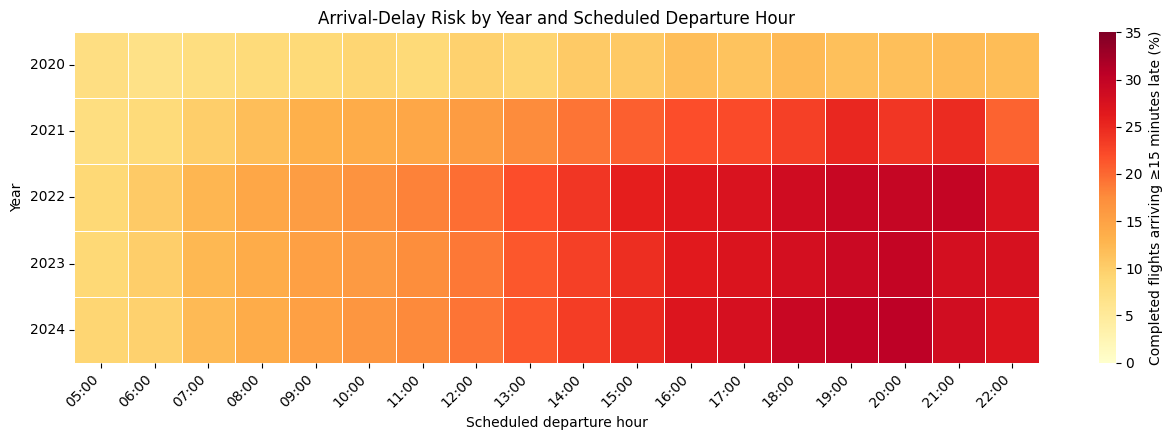

Saved: /content/drive/MyDrive/MIT805_Airline_Delays/output/part2/figures/year_hour_late_arrival_heatmap.png
Values plotted: 90


In [ ]:
# ## 5.2 Delay Risk by Departure Hour
# To understand how reliability changes during the operating day, delay rates are visualised using a heatmap showing both annual and hourly trends.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = PART2_OUTPUT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plot_df = pd.DataFrame([row.asDict() for row in rows])
plot_df["late_rate_completed_pct"] = (
    100 * plot_df["late_completed_arrivals"] / plot_df["completed_arrivals"]
)

heatmap_data = (
    plot_df[plot_df["ScheduledDepHour"].between(5, 22)]
    .pivot(
        index="Year",
        columns="ScheduledDepHour",
        values="late_rate_completed_pct"
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 4.5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    vmin=0,
    vmax=35,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Completed flights arriving ≥15 minutes late (%)"},
    ax=ax
)

ax.set(
    title="Arrival-Delay Risk by Year and Scheduled Departure Hour",
    xlabel="Scheduled departure hour",
    ylabel="Year"
)
ax.set_xticklabels([f"{hour:02d}:00" for hour in heatmap_data.columns],
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
chart_path = figures_dir / "year_hour_late_arrival_heatmap.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)
print("Values plotted:", heatmap_data.size)

In [ ]:
# ## 5.3 Catalyst Optimizer Analysis
# The physical execution plan is examined to verify Spark's use of distributed processing strategies.

plan_lines = plan_text.splitlines()

keywords = (
    "Scan csv",
    "FileScan csv",
    "Filter",
    "Project",
    "HashAggregate",
    "SortAggregate",
    "Exchange",
    "Sort",
    "AdaptiveSparkPlan",
)

for number, line in enumerate(plan_lines, start=1):
    if any(keyword.lower() in line.lower() for keyword in keywords):
        print(f"{number:03d}: {line[:220]}")

002: AdaptiveSparkPlan (12)
003: +- Sort (11)
004:    +- Exchange (10)
005:       +- Project (9)
006:          +- HashAggregate (8)
007:             +- Exchange (7)
008:                +- HashAggregate (6)
009:                   +- Project (5)
010:                      +- Project (4)
011:                         +- Project (3)
012:                            +- Filter (2)
013:                               +- Scan csv  (1)
016: (1) Scan csv 
020: PushedFilters: [IsNotNull(Year), IsNotNull(CRSDepTime)]
023: (2) Filter
027: (3) Project
031: (4) Project
035: (5) Project
039: (6) HashAggregate
046: (7) Exchange
050: (8) HashAggregate
057: (9) Project
061: (10) Exchange
065: (11) Sort
069: (12) AdaptiveSparkPlan


In [ ]:
for start, end in [(39, 53), (57, 68)]:
    print(f"\n--- Plan lines {start}–{end} ---")
    for number in range(start, min(end, len(plan_lines)) + 1):
        print(f"{number:03d}: {plan_lines[number - 1][:350]}")


--- Plan lines 39–53 ---
039: (6) HashAggregate
040: Input [12]: [Year#127, Cancelled#130, Diverted#131, ArrDelay#132, CarrierDelay#134, WeatherDelay#135, NASDelay#136, SecurityDelay#137, LateAircraftDelay#138, ScheduledDepHour#140, CompletedArrival#142, LateCompletedArrival#143]
041: Keys [2]: [Year#127, ScheduledDepHour#140]
042: Functions [11]: [partial_count(1), partial_sum(CASE WHEN (Cancelled#130 = 1.0) THEN 1 ELSE 0 END), partial_sum(CASE WHEN (Diverted#131 = 1.0) THEN 1 ELSE 0 END), partial_sum(CompletedArrival#142), partial_sum(LateCompletedArrival#143), partial_sum(CASE WHEN (LateCompletedArrival#143 = 1) THEN ArrDelay#132 ELSE 0.0 END), partial_sum(CASE WHEN (LateC
043: Aggregate Attributes [11]: [count#184L, sum#185L, sum#186L, sum#187L, sum#188L, sum#189, sum#190, sum#191, sum#192, sum#193, sum#194]
044: Results [13]: [Year#127, ScheduledDepHour#140, count#195L, sum#196L, sum#197L, sum#198L, sum#199L, sum#200, sum#201, sum#202, sum#203, sum#204, sum#205]
045: 
046: (7) Ex

In [ ]:
# ## 5.4 Root Causes of Delays
# Delay minutes are analysed across the five official delay-cause categories to determine which factors contribute most heavily to overall disruption.

cause_names = (
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
)

total_late_minutes = sum(
    row["late_arrival_delay_minutes"] or 0
    for row in rows
)

cause_totals = {
    name: sum(row[f"{name}_minutes"] or 0 for row in rows)
    for name in cause_names
}

total_attributed_minutes = sum(cause_totals.values())
difference = total_late_minutes - total_attributed_minutes

print(f"Late arrival-delay minutes: {total_late_minutes:,.0f}")
print(f"Attributed cause minutes:   {total_attributed_minutes:,.0f}")
print(f"Difference:                 {difference:,.0f}")

for name, minutes in cause_totals.items():
    share = 100 * minutes / total_attributed_minutes
    print(f"{name:22s} {minutes:>15,.0f} minutes  {share:6.2f}%")

Late arrival-delay minutes: 385,651,857
Attributed cause minutes:   385,650,737
Difference:                 1,120
CarrierDelay               145,996,458 minutes   37.86%
WeatherDelay                22,822,955 minutes    5.92%
NASDelay                    69,459,766 minutes   18.01%
SecurityDelay                  871,910 minutes    0.23%
LateAircraftDelay          146,499,648 minutes   37.99%


In [ ]:
# ## 5.5 Reliability by Departure Period
# Flights are grouped into Early Morning, Midday, and Evening periods to analyse how operational performance changes throughout the day.

period_results = (
    small_results
    .withColumn(
        "DeparturePeriod",
        F.when(F.col("ScheduledDepHour").between(5, 9), "Early morning")
         .when(F.col("ScheduledDepHour").between(10, 15), "Midday")
         .when(F.col("ScheduledDepHour").between(16, 22), "Evening")
         .otherwise("Other hours")
    )
    .filter(F.col("DeparturePeriod") != "Other hours")
    .groupBy("Year", "DeparturePeriod")
    .agg(
        F.sum("scheduled_flights").alias("scheduled_flights"),
        F.sum("completed_arrivals").alias("completed_arrivals"),
        F.sum("late_completed_arrivals").alias("late_completed_arrivals"),
        F.sum("late_arrival_delay_minutes").alias("late_arrival_delay_minutes"),
        *[
            F.sum(f"{name}_minutes").alias(f"{name}_minutes")
            for name in cause_names
        ]
    )
    .withColumn(
        "late_rate_completed_pct",
        F.round(
            100 * F.col("late_completed_arrivals") / F.col("completed_arrivals"),
            2
        )
    )
    .withColumn(
        "attributed_minutes",
        sum(F.col(f"{name}_minutes") for name in cause_names)
    )
    .withColumn(
        "late_aircraft_share_pct",
        F.round(
            100 * F.col("LateAircraftDelay_minutes")
            / F.col("attributed_minutes"),
            2
        )
    )
    .withColumn(
        "carrier_share_pct",
        F.round(
            100 * F.col("CarrierDelay_minutes")
            / F.col("attributed_minutes"),
            2
        )
    )
    .orderBy("Year", "DeparturePeriod")
)

period_results.select(
    "Year",
    "DeparturePeriod",
    "scheduled_flights",
    "late_completed_arrivals",
    "late_rate_completed_pct",
    "late_aircraft_share_pct",
    "carrier_share_pct"
).show(15, truncate=False)

+----+---------------+-----------------+-----------------------+-----------------------+-----------------------+-----------------+
|Year|DeparturePeriod|scheduled_flights|late_completed_arrivals|late_rate_completed_pct|late_aircraft_share_pct|carrier_share_pct|
+----+---------------+-----------------+-----------------------+-----------------------+-----------------------+-----------------+
|2020|Early morning  |1331910          |98655                  |7.92                   |14.33                  |53.55            |
|2020|Evening        |1498500          |165089                 |11.76                  |34.46                  |36.98            |
|2020|Midday         |1822935          |164705                 |9.6                    |33.63                  |38.95            |
|2021|Early morning  |1703456          |178958                 |10.7                   |17.35                  |58.68            |
|2021|Evening        |1961240          |443430                 |23.14              

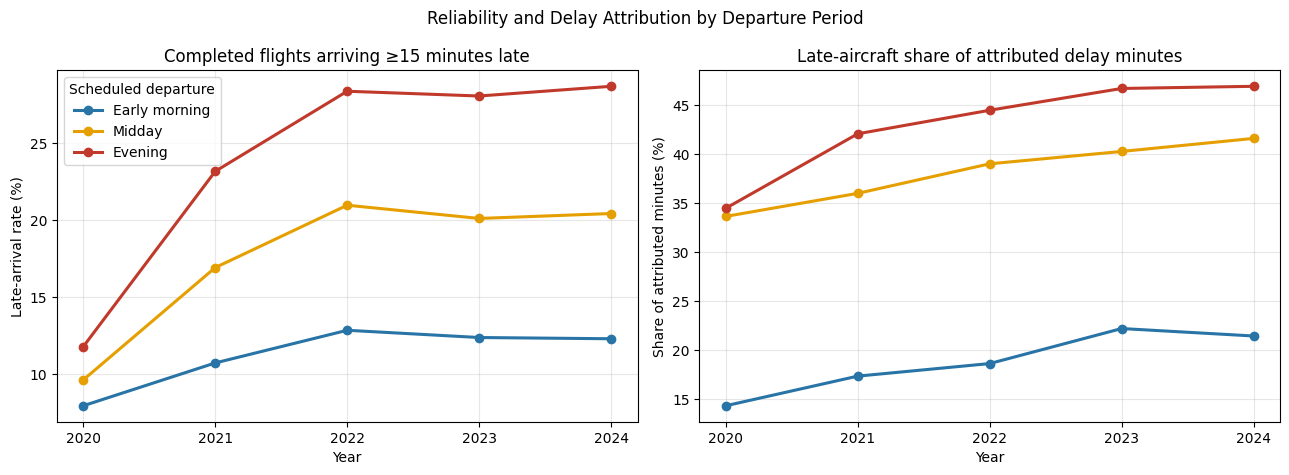

Saved: /content/drive/MyDrive/MIT805_Airline_Delays/output/part2/figures/departure_period_reliability_and_causes.png


In [ ]:
# ## 5.6 Delay Cascading Effects
# Trend charts are used to evaluate whether delays propagate through airline schedules as the operating day progresses.

import matplotlib.pyplot as plt
import seaborn as sns

period_pd = period_results.toPandas()

period_order = ["Early morning", "Midday", "Evening"]
colors = {
    "Early morning": "#2874A6",
    "Midday": "#E69F00",
    "Evening": "#C0392B",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

for period in period_order:
    subset = period_pd[
        period_pd["DeparturePeriod"] == period
    ].sort_values("Year")

    axes[0].plot(
        subset["Year"],
        subset["late_rate_completed_pct"],
        marker="o",
        linewidth=2.2,
        color=colors[period],
        label=period
    )
    axes[1].plot(
        subset["Year"],
        subset["late_aircraft_share_pct"],
        marker="o",
        linewidth=2.2,
        color=colors[period],
        label=period
    )

axes[0].set(
    title="Completed flights arriving ≥15 minutes late",
    xlabel="Year",
    ylabel="Late-arrival rate (%)"
)

axes[1].set(
    title="Late-aircraft share of attributed delay minutes",
    xlabel="Year",
    ylabel="Share of attributed minutes (%)"
)

for ax in axes:
    ax.set_xticks([2020, 2021, 2022, 2023, 2024])
    ax.grid(alpha=0.3)

axes[0].legend(title="Scheduled departure", loc="upper left")
fig.suptitle("Reliability and Delay Attribution by Departure Period")
fig.tight_layout()

chart_path = figures_dir / "departure_period_reliability_and_causes.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

In [ ]:
# # Section 6: Execution Evidence and Export Verification
# To support reproducibility and assessment requirements, execution metadata, physical-plan evidence, summary reports, and analytical outputs are exported and verified.

ui_url = spark.sparkContext.uiWebUrl
print("Spark UI URL:", ui_url)

app_id = spark.sparkContext.applicationId
print("Spark application ID:", app_id)

print("Default shuffle partitions:",
      spark.conf.get("spark.sql.shuffle.partitions"))

Spark UI URL: http://723fe5b066b8:4040
Spark application ID: local-1790406374841
Default shuffle partitions: 200


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(4040, path="/jobs/index.html")

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(4040, path="/jobs/index.html")

<IPython.core.display.Javascript object>

In [ ]:
from datetime import datetime

execution_report = f"""MIT 805 Part 2 — Spark Execution Evidence
Generated: {datetime.now().isoformat(timespec="seconds")}

Spark application ID: {spark.sparkContext.applicationId}
Spark version: {spark.version}
Spark UI URL reported by Spark: {spark.sparkContext.uiWebUrl}
Configured spark.sql.shuffle.partitions: {spark.conf.get("spark.sql.shuffle.partitions")}

Input validation
----------------
Selected CSV files: 60
Observed year-month periods: 60
Missing periods: none
Processed input size: 14.130 GB (13.159 GiB)

Action executed
---------------
hourly_by_year.collect()

Output
------
Year-hour groups returned: {len(rows)}
Valid-hour scheduled-flight records: {sum(row["scheduled_flights"] for row in rows):,}
Late completed arrivals: {sum(row["late_completed_arrivals"] for row in rows):,}

Physical-plan evidence
----------------------
The saved formatted physical plan is stored in:
{plan_path}

Key confirmed operators:
- Scan csv
- Filter
- Project
- Partial HashAggregate keyed by Year and ScheduledDepHour
- Exchange: hashpartitioning(Year, ScheduledDepHour, 200)
- Final HashAggregate keyed by Year and ScheduledDepHour
- Exchange: rangepartitioning(Year ASC, ScheduledDepHour ASC, 200)
- Sort
- AdaptiveSparkPlan

Interpretation
--------------
The hash-partitioning Exchange is the grouping shuffle required to bring
identical (Year, ScheduledDepHour) keys together for final aggregation.
The range-partitioning Exchange is used for final ordering, not for the
analytical groupBy reduction.
"""

report_path = evidence_dir / "spark_execution_summary.txt"
report_path.write_text(execution_report)

print(execution_report)
print("Saved:", report_path)

MIT 805 Part 2 — Spark Execution Evidence
Generated: 2026-09-26T07:33:51

Spark application ID: local-1790406374841
Spark version: 4.0.4
Spark UI URL reported by Spark: http://723fe5b066b8:4040
Configured spark.sql.shuffle.partitions: 200

Input validation
----------------
Selected CSV files: 60
Observed year-month periods: 60
Missing periods: none
Processed input size: 14.130 GB (13.159 GiB)

Action executed
---------------
hourly_by_year.collect()

Output
------
Year-hour groups returned: 120
Valid-hour scheduled-flight records: 31,339,835
Late completed arrivals: 5,655,716

Physical-plan evidence
----------------------
The saved formatted physical plan is stored in:
/content/drive/MyDrive/MIT805_Airline_Delays/output/part2/execution_evidence/year_hour_physical_plan.txt

Key confirmed operators:
- Scan csv
- Filter
- Project
- Partial HashAggregate keyed by Year and ScheduledDepHour
- Exchange: hashpartitioning(Year, ScheduledDepHour, 200)
- Final HashAggregate keyed by Year and Sche

In [ ]:
import csv

period_rows = period_results.collect()
period_table_path = tables_dir / "year_departure_period_aggregation.csv"

with period_table_path.open("w", newline="") as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=period_results.columns
    )
    writer.writeheader()
    writer.writerows(row.asDict() for row in period_rows)

print("Period groups saved:", len(period_rows))
print("Saved:", period_table_path)
print("Physical plan exists:", plan_path.is_file())
print("Execution summary exists:", report_path.is_file())
print("Heatmap exists:",
      (figures_dir / "year_hour_late_arrival_heatmap.png").is_file())
print("Period chart exists:",
      (figures_dir / "departure_period_reliability_and_causes.png").is_file())

Period groups saved: 15
Saved: /content/drive/MyDrive/MIT805_Airline_Delays/output/part2/tables/year_departure_period_aggregation.csv
Physical plan exists: True
Execution summary exists: True
Heatmap exists: True
Period chart exists: True
